<a href="https://colab.research.google.com/github/theduardomaciel/cc-dl/blob/main/tasks/task-02-halfmoon-perceptron/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
class Perceptron:
    def __init__(self, seed=0, input_size=2, learning_rate=0.01, epochs=100):
        self.seed = seed
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.input_size = input_size
        self._init_weights()

    def _init_weights(self):
        rng = np.random.default_rng(self.seed)
        ### START CODE HERE ###
        ### TODO: Initialize weights with small Gaussian noise using rng.normal

        # Vetor de pesos com tamanho input_size + 1 (features + bias),
        # amostrado de uma gaussiana com média 0 e desvio padrão 0.5.
        self.weights = rng.normal(loc=0.0, scale=0.5, size=self.input_size + 1)

        ### END CODE HERE ###

    def activation(self, x):
        ### START CODE HERE ###
        ### TODO: Implement the step activation function

        # Degrau: +1 se x >= 0, -1 caso contrário.
        return np.where(x >= 0, 1, -1)

        ### END CODE HERE ###

    def predict(self, X):
        ### START CODE HERE ###
        ### TODO: Add bias term, compute dot product with weights, apply activation

        # Adiciona a coluna de bias (1s), calcula z = X · w e aplica o degrau.
        X_bias = np.c_[X, np.ones(X.shape[0])]
        z = np.dot(X_bias, self.weights)
        return self.activation(z)

        ### END CODE HERE ###

    def fit(self, X, y):
        ### START CODE HERE ###
        ### TODO: Implement the perceptron learning algorithm

        # Aprendizado online: para cada amostra classificada errado, ajusta
        # os pesos na direção que reduz o erro (w <- w + learning_rate * y * x).
        X_bias = np.c_[X, np.ones(X.shape[0])]
        for epoch in range(self.epochs):
            for i in range(X_bias.shape[0]):
                z = np.dot(X_bias[i], self.weights)
                prediction = self.activation(z)
                if prediction != y[i]:
                    self.weights += self.learning_rate * y[i] * X_bias[i]

        ### END CODE HERE ###

In [3]:
def generate_halfmoon(
    seed=0,
    n_samples=1000,
    rad_min=50,
    rad_max=100,
    ang_min=45,
    ang_max=220,
    dist_type="normal",
    rad_std=10,
    ang_std=30.0,
    x0=0.0,
    y0=0.0,
    return_as_array=False,
):
    """
    Generate 2D data in a halfmoon shape using polar coordinate sampling.

    Parameters:
        n_samples (int): Number of points to generate.
        rad_min (float): Minimum radius.
        rad_max (float): Maximum radius.
        ang_min (float): Minimum angle in degrees.
        ang_max (float): Maximum angle in degrees.
        dist_type (str): 'uniform' or 'normal'.
        rad_std (float): Std dev for radius (used if dist_type='normal').
        ang_std (float): Std dev for angle (used if dist_type='normal').
        x0 (float): X offset of the moon.
        y0 (float): Y offset of the moon.
        return_as_array (bool): If True, returns Nx2 array. Else, returns (x, y) tuple.

    Returns:
        np.ndarray or tuple of np.ndarray: Data points (x, y).
    """
    np.random.seed(seed)

    dist_type = dist_type.lower()
    if dist_type not in ["uniform", "normal"]:
        raise ValueError("dist_type must be either 'uniform' or 'normal'.")

    if dist_type == "uniform":
        r = np.random.uniform(rad_min, rad_max, size=n_samples)
        t = np.random.uniform(ang_min, ang_max, size=n_samples)
    else:  # normal
        r_mean = (rad_max + rad_min) / 2.0
        t_mean = (ang_max + ang_min) / 2.0
        r = np.random.normal(loc=r_mean, scale=rad_std, size=n_samples)
        t = np.random.normal(loc=t_mean, scale=ang_std, size=n_samples)
        r = np.clip(r, a_min=0, a_max=None)  # avoid negative radii

    x = x0 + r * np.cos(np.deg2rad(t))
    y = y0 + r * np.sin(np.deg2rad(t))

    if return_as_array:
        return np.vstack((x, y)).T
    else:
        return x.reshape(-1, 1), y.reshape(-1, 1)


def generate_halfmoon_data(n_samples=1000):
    x11, x12 = generate_halfmoon(
        n_samples=n_samples // 2,
        dist_type="normal",
        return_as_array=False,
        x0=0,
        y0=0,
        ang_min=0,
        ang_max=180,
    )
    x21, x22 = generate_halfmoon(
        n_samples=n_samples // 2,
        dist_type="normal",
        return_as_array=False,
        x0=75,
        y0=80,
        ang_min=-180,
        ang_max=0,
    )

    X1 = np.hstack([x11, x12])
    X2 = np.hstack([x21, x22])
    X = np.vstack([X1, X2])
    y = np.hstack([np.ones(n_samples // 2), -1 * np.ones(n_samples // 2)])
    return X, y


def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, alpha=0.3, levels=[-1, 0, 1], colors=["red", "blue"])
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolor="k", s=20)
    plt.title("Perceptron Decision Boundary on Halfmoon Data")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

Test Accuracy: 0.77


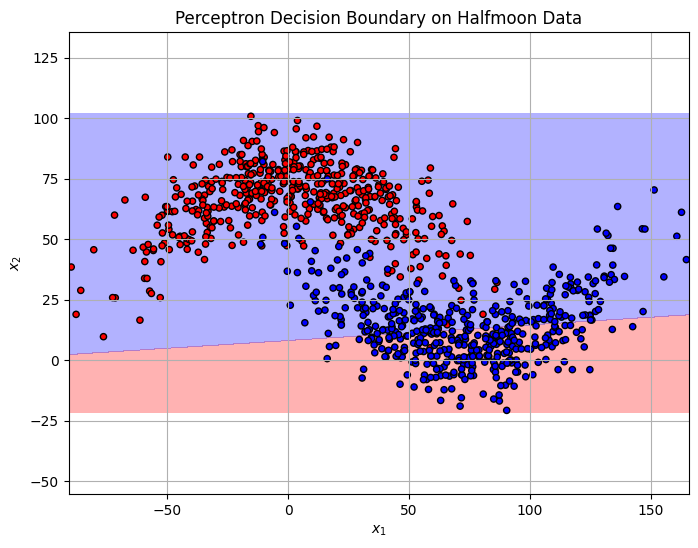

In [4]:
def main():
    X, y = generate_halfmoon_data(n_samples=1000)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = Perceptron(epochs=100)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    acc = np.mean(predictions == y_test)
    print(f"Test Accuracy: {acc:.2f}")
    plot_decision_boundary(model, X, y)


if __name__ == "__main__":
    main()